# Day 70 – Model Evaluation Metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             f1_score, roc_curve, roc_auc_score,
                             mean_absolute_error, mean_squared_error)
from sklearn.datasets import make_classification, make_regression

## Classification Metrics

In [2]:
# Create classification dataset
X, y = make_classification(n_samples=1000, n_features=5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [3]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
 [[89  8]
 [16 87]]
Accuracy: 0.88
Precision: 0.9157894736842105
Recall: 0.8446601941747572
F1 Score: 0.8787878787878788


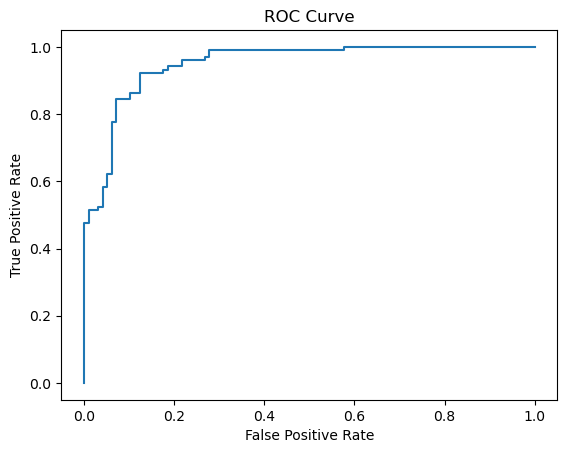

AUC Score: 0.9498548693824442


In [4]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", auc_score)

## Regression Metrics

In [5]:
# Create regression dataset
X_reg, y_reg = make_regression(n_samples=1000, n_features=3, noise=10, random_state=42)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train Linear Regression
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

In [6]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 8.204645161912483
MSE: 102.9107411798956
RMSE: 10.144493145539386
